In [1]:
# import libraries
import requests
import re
import pandas as pd
from pandas import DataFrame

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
import random as rd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

import graphviz

from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import silhouette_samples, silhouette_score
import sklearn
from sklearn.cluster import KMeans

from sklearn import preprocessing

import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import ward, dendrogram

In [2]:
# install ldaVis
!pip install pyLDAvis

In [3]:
from __future__ import print_function
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [4]:
# load in raw dataset
data = pd.read_csv('Raw Master Data.csv')
data.head()

,LABEL,Content
0,universal healthcare,universal basic income offers strings attached...
1,universal healthcare,universal basic income politically controversi...
2,universal healthcare,senators grilled robert kennedy trump pick hea...
3,universal healthcare,health secretary says reform poverty ambition ...
4,universal healthcare,initiative follows pressure from several artis...


In [5]:
# Create CountVectorizer
MyCountV=CountVectorizer(
        input="content",
        lowercase=True,
        stop_words = "english",
        max_features = 200,
        token_pattern = r'\b[a-zA-Z]{4,}\b' # remove words less than 4 characters
        )

In [6]:
dtm_tf = MyCountV.fit_transform(data['Content'])
tfidf_vectorizer = TfidfVectorizer(**MyCountV.get_params())
dtm_tfidf = tfidf_vectorizer.fit_transform(data['Content']).astype('float64')

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. <class 'numpy.int64'> 'dtype' will be converted to np.float64.
  warnings.warn(


In [7]:
# Create model
lda_model = LatentDirichletAllocation(n_components=9, max_iter=500,
                                      learning_method='online',
                                   batch_size=5000,
                                      evaluate_every = -1,
                                      n_jobs = -1) # using 9 components because of 9 labels in dataset
lda_model.fit(dtm_tf)

lda_tfidf = LatentDirichletAllocation(n_components=9, max_iter=50,
                                      learning_method='online',
                                   batch_size=5000,
                                      evaluate_every = -1,
                                      n_jobs = -1)
lda_tfidf.fit(dtm_tfidf)

LatentDirichletAllocation(batch_size=5000, learning_method='online',
                          max_iter=50, n_components=9, n_jobs=-1)

In [8]:
# display the model
lda_vis = pyLDAvis.lda_model.prepare(lda_model, dtm_tf, MyCountV)
pyLDAvis.display(lda_vis)

In [9]:
# fit the vectorizer to the data again for other lda model
Vect1 = MyCountV.fit_transform(data['Content'])

CountVDF = pd.DataFrame(Vect1.toarray(), columns=MyCountV.get_feature_names_out())

# Check results
print(CountVDF)

      able  absolutely  access  actually  administration  afford  agree  \
0        0           0       0         0               0       0      0   
1        0           0       0         0               0       0      0   
2        0           0       0         0               0       0      0   
3        0           0       0         0               0       0      0   
4        0           0       0         0               0       0      0   
...    ...         ...     ...       ...             ...     ...    ...   
2104     0           0       0         0               0       0      0   
2105     0           0       0         1               0       0      0   
2106     0           0       0         0               0       0      0   
2107     0           0       0         0               0       0      0   
2108     0           0       0         0               0       0      0   

      america  american  americans  ...  work  working  works  world  worse  \
0           0       

In [10]:
# clean data
for nextcol in CountVDF.columns:
    if(bool(re.search(r'[^a-zA-Z]', nextcol))):
       CountVDF=CountVDF.drop([nextcol], axis=1)

for nextcol in CountVDF.columns:
    if(len(str(nextcol))<=4): # remove words less than 4
         CountVDF=CountVDF.drop([nextcol], axis=1)


print(CountVDF)

      absolutely  access  actually  administration  afford  agree  america  \
0              0       0         0               0       0      0        0   
1              0       0         0               0       0      0        0   
2              0       0         0               0       0      0        0   
3              0       0         0               0       0      0        0   
4              0       0         0               0       0      0        0   
...          ...     ...       ...             ...     ...    ...      ...   
2104           0       0         0               0       0      0        0   
2105           0       0         1               0       0      0        0   
2106           0       0         0               0       0      0        0   
2107           0       0         0               0       0      0        0   
2108           0       0         0               0       0      0        5   

      american  americans  arent  ...  united  universal  worki

In [11]:
# check top words per topic
for index,topic in enumerate(lda_model.components_):
    print(f'THE TOP 15 WORDS FOR TOPIC #{index}')
    print([MyCountV.get_feature_names_out()[i] for i in topic.argsort()[-15:]])
    print('\n')

THE TOP 15 WORDS FOR TOPIC #0
['administration', 'insurance', 'office', 'universal', 'coverage', 'states', 'united', 'donald', 'care', 'president', 'government', 'services', 'federal', 'trump', 'health']


THE TOP 15 WORDS FOR TOPIC #1
['isnt', 'world', 'social', 'live', 'understand', 'country', 'want', 'data', 'just', 'know', 'like', 'universal', 'people', 'dont', 'healthcare']


THE TOP 15 WORDS FOR TOPIC #2
['want', 'americans', 'paying', 'make', 'costs', 'cover', 'companies', 'just', 'taxes', 'people', 'government', 'dont', 'money', 'medical', 'insurance']


THE TOP 15 WORDS FOR TOPIC #3
['surgery', 'times', 'just', 'months', 'cancer', 'cost', 'health', 'doctor', 'care', 'time', 'wait', 'treatment', 'years', 'hospital', 'insurance']


THE TOP 15 WORDS FOR TOPIC #4
['example', 'going', 'look', 'canada', 'universal', 'choose', 'simply', 'state', 'healthcare', 'best', 'flair', 'removed', 'option', 'public', 'private']


THE TOP 15 WORDS FOR TOPIC #5
['costs', 'quality', 'drug', 'read'

In [12]:
# save ldavis as hmtl output
pyLDAvis.save_html(lda_vis, 'lda.html')

In [13]:
# Create other visuals with new LDA models
NUM_TOPICS= 9
lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, max_iter=500, learning_method='online')

lda_Z_DF = lda_model.fit_transform(CountVDF)
print(lda_Z_DF.shape)

def print_topics(model, vectorizer, top_n=10):
    for idx, topic in enumerate(model.components_):
        print("Topic %d:" % (idx))
        print([(vectorizer.get_feature_names_out()[i], topic[i])
                    for i in topic.argsort()[:-top_n - 1:-1]])

print("LDA Model:")
print_topics(lda_model, MyCountV)

(2109, 9)
LDA Model:
Topic 0:
[('level', 467.18420297795916), ('higher', 226.93474342618134), ('hospital', 135.608286137148), ('power', 101.77202651208178), ('people', 77.64242593981373), ('best', 72.70383473916502), ('poor', 72.6680304241753), ('needed', 65.8288324131773), ('high', 57.33674363543421), ('dollars', 53.48256721102194)]
Topic 1:
[('mean', 296.36965849057714), ('emergency', 214.79211125059842), ('million', 156.59672058015144), ('america', 115.35223292724521), ('choose', 90.94835397983212), ('fact', 87.54887708466111), ('issues', 71.00481833733278), ('order', 65.7005091342105), ('free', 64.82577065056225), ('healthcare', 62.05432646024781)]
Topic 2:
[('drugs', 544.633107621031), ('free', 110.17359610045753), ('price', 109.9778517395504), ('number', 107.95598455135988), ('american', 99.55788181786168), ('control', 99.42685553364903), ('benefits', 62.077467763866984), ('population', 59.691528008368884), ('paying', 39.78089297826384), ('live', 37.64244842315378)]
Topic 3:
[('e

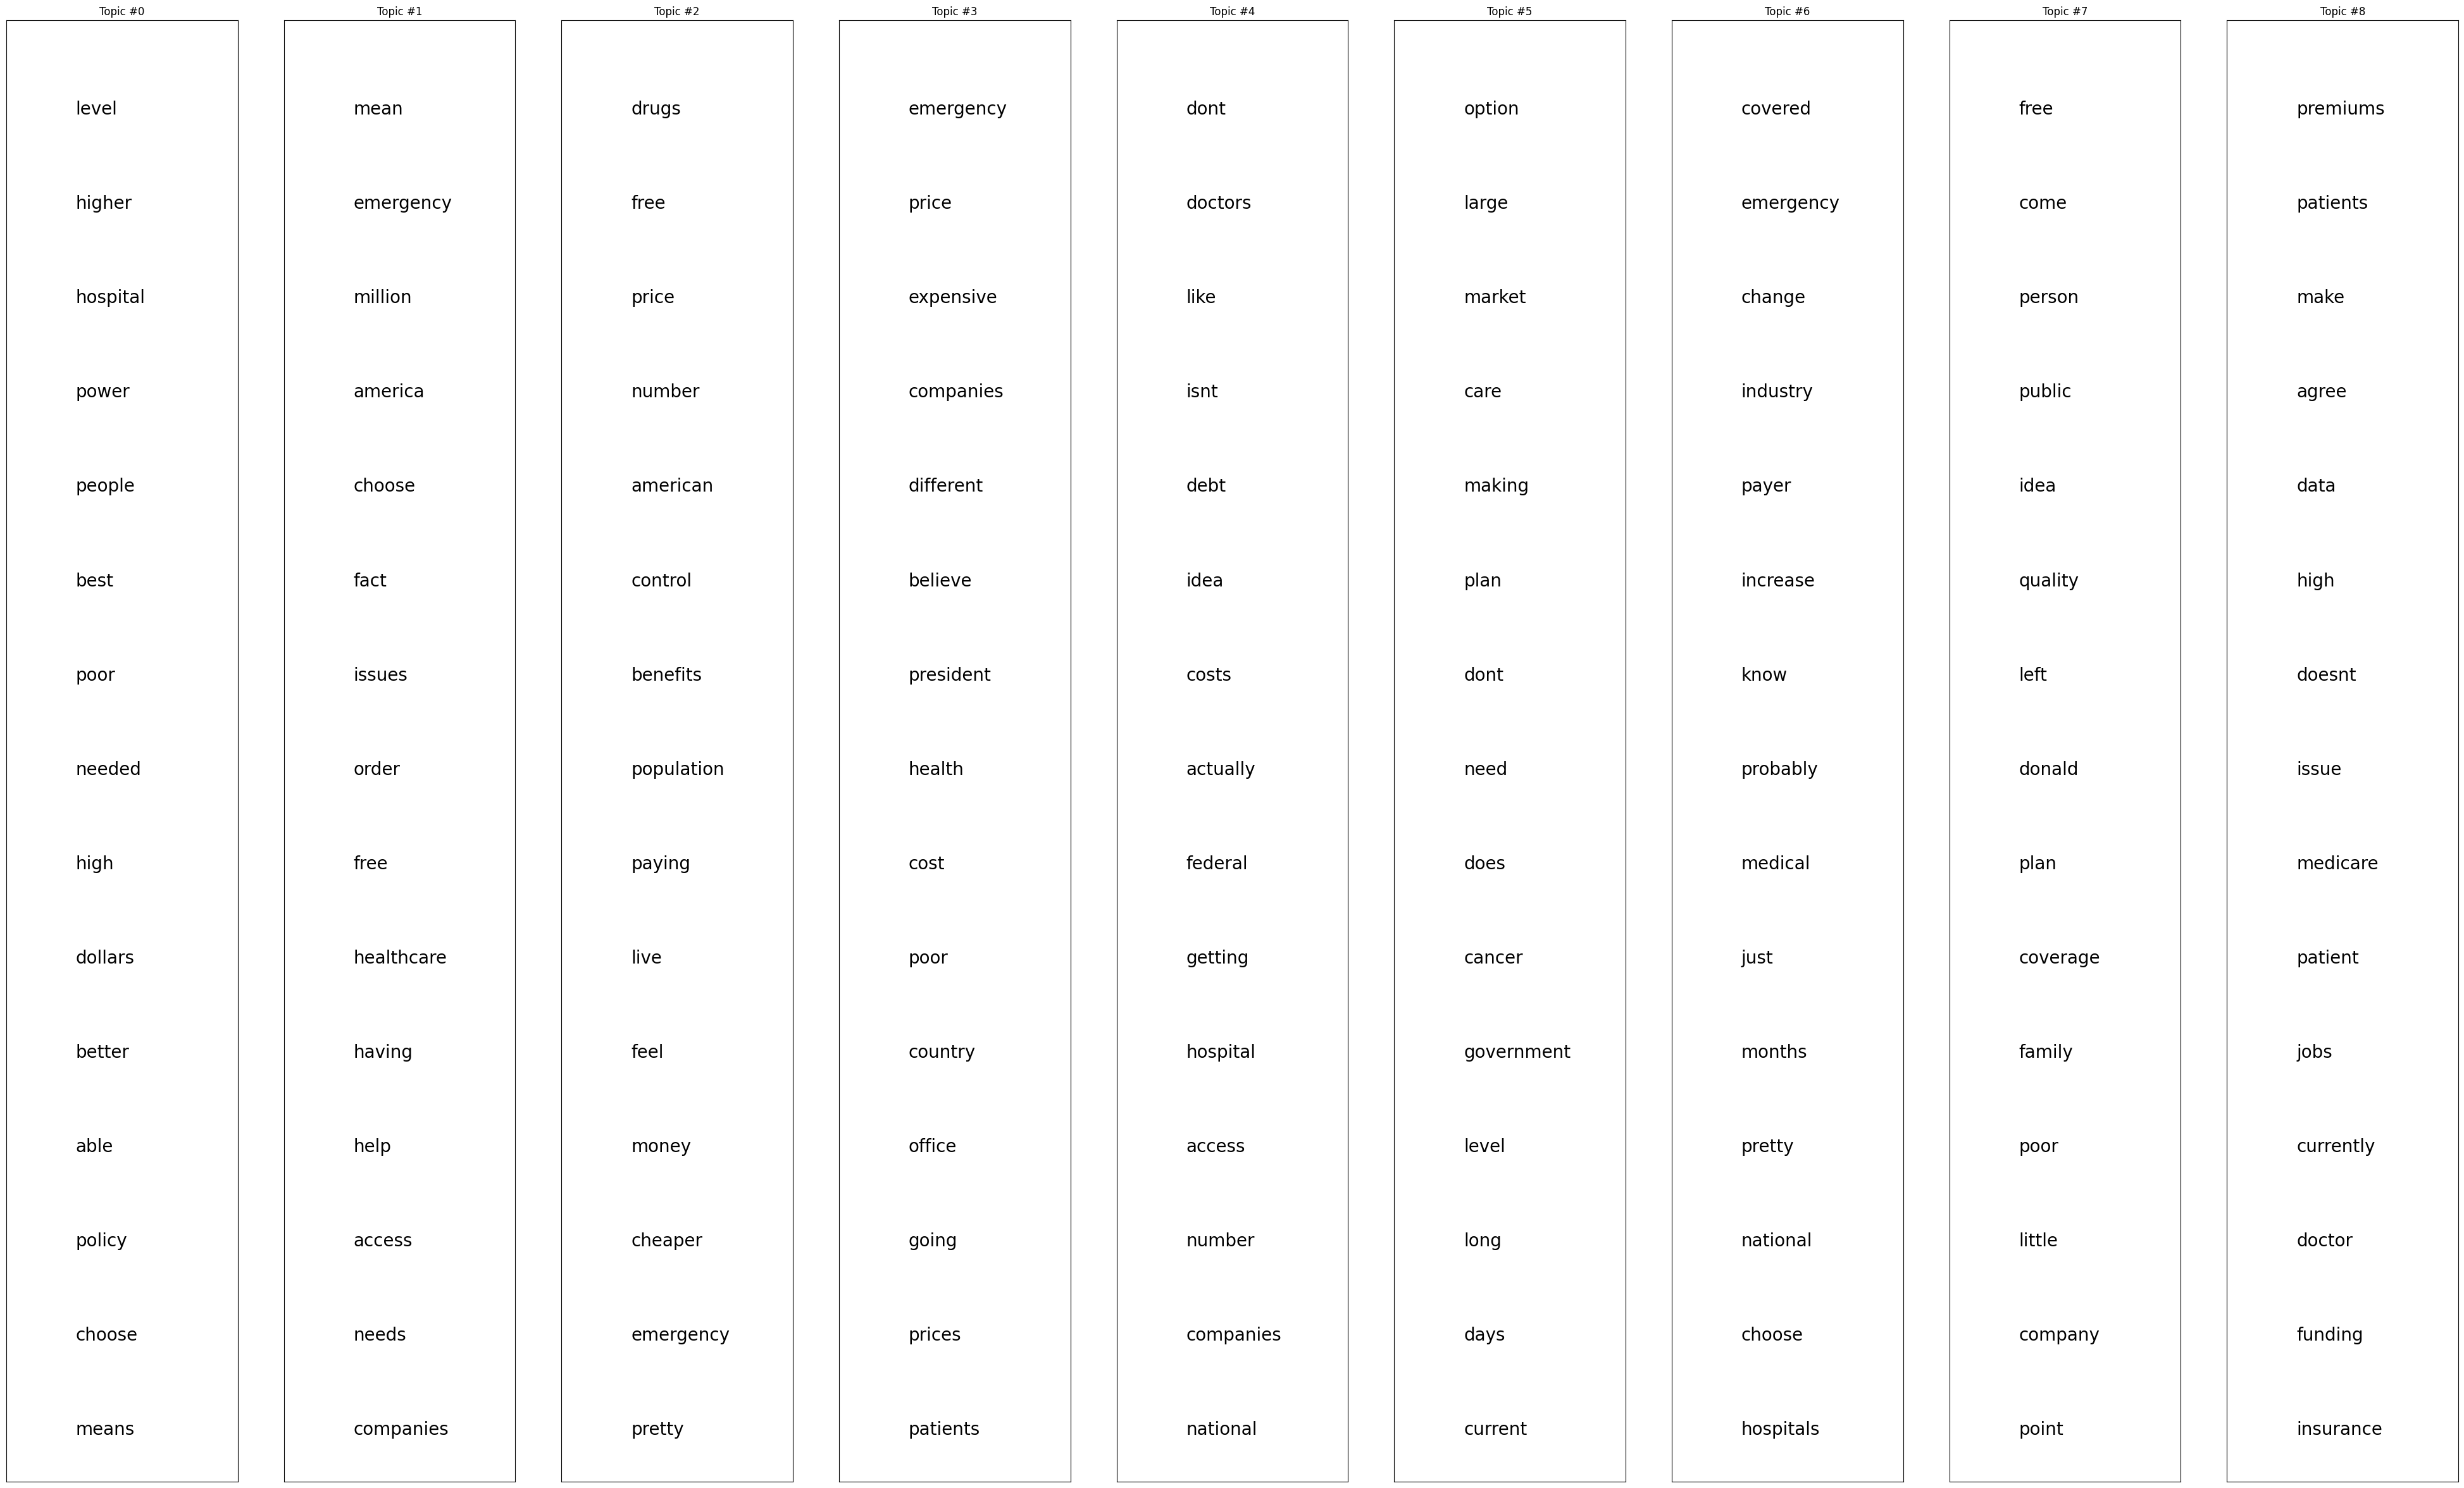

In [14]:
# Create figure to show top words per topic
plt.figure(figsize=(50,30))
word_topic = np.array(lda_model.components_)

word_topic = word_topic.transpose()

num_top_words = 15
vocab_array = np.asarray(MyCountV.get_feature_names_out())


fontsize_base = 40

for t in range(NUM_TOPICS):
    plt.subplot(1, NUM_TOPICS, t + 1)
    plt.ylim(0, num_top_words + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title('Topic #{}'.format(t))
    top_words_idx = np.argsort(word_topic[:,t])[::-1]  # descending order
    top_words_idx = top_words_idx[:num_top_words]
    top_words = vocab_array[top_words_idx]
    top_words_shares = word_topic[top_words_idx, t]
    for i, (word, share) in enumerate(zip(top_words, top_words_shares)):
        plt.text(0.3, num_top_words-i-0.5, word, fontsize=fontsize_base/2)
                 ##fontsize_base*share)


plt.savefig("TopicsVis.pdf")
plt.show()